# SciPy and Pyomo on the LyoPRONTO paper optimizer cases

This notebook reruns the three primary-drying optimizations in Figure 15 of the original LyoPRONTO paper: chamber pressure only, shelf temperature only, and both controls together. The purpose is a direct comparison of the current SciPy and Pyomo.DAE implementations.

Paper case: 2 mL of 5% mannitol in 398 Schott 6R vials on one shelf of a Millrock REVO. The fixed-setpoint reference is 150 mTorr and 30 °C, with a reported drying time of 5.11 h. The paper reports 2.99 h for pressure optimization, 2.11 h for shelf-temperature optimization, and 1.96 h for joint optimization.

Source: G. Shivkumar et al., [*LyoPRONTO: an Open-Source Lyophilization Process Optimization Tool*](https://doi.org/10.1208/s12249-019-1532-7), AAPS PharmSciTech 20, 328 (2019).

The engineering result of this tutorial is the **fastest implementable cycle** — the one an actuator-limited machine can actually run. The paper cases come first because they are the validation that licenses it: they show the current SciPy and Pyomo.DAE implementations agree with a published reference and with each other. Only after that does the notebook ask the question the sequential optimizer cannot formulate at all.


## Setup

Run this notebook from the repository root. Pyomo and IPOPT are optional dependencies:

```bash
python -m pip install -e ".[dev,pyomo]"
idaes get-extensions --extra petsc
jupyter lab docs/examples/current_main_joint_optimizer_comparison.ipynb
```


In [1]:
# Papermill parameters. CI uses a coarser SciPy step and the same compact mesh.
a1 = 16.0
kc = 2.75e-4
scipy_dt = 0.01
point_budget = 49
sensitivity_point_budgets = [25, 49, 73]
scipy_refinement_dt_values = [0.02, 0.01, 0.005]
shelf_sweep_rates_c_hr = [15.0, 30.0, 60.0]
ncp = 3
final_dried_fraction = 1.0

# Pyomo-only extension of the paper's joint-control case.
initial_pressure_torr = 0.15
initial_shelf_temperature_c = 30.0
pressure_ramp_rate_torr_hr = 0.05
shelf_temperature_ramp_rate_c_hr = 30.0


In [2]:
from importlib.metadata import version
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from examples.current_main_comparison import matched_nfe_for_point_budget
from examples.current_main_optimizer_comparison import (
    comparison_inputs as shelf_inputs,
    run_discretization_sensitivity as shelf_sensitivity,
    run_pyomo_dae as run_shelf_pyomo,
    run_scipy_reference as run_shelf_scipy,
)
from examples.current_main_pressure_optimizer_comparison import (
    comparison_inputs as pressure_inputs,
    run_discretization_sensitivity as pressure_sensitivity,
    run_pyomo_dae as run_pressure_pyomo,
    run_scipy_reference as run_pressure_scipy,
)
from lyopronto.pyomo_models import solve_dae_joint_optimization
from examples.current_main_joint_optimizer_comparison import (
    comparison_inputs as joint_inputs,
    run_discretization_sensitivity as joint_sensitivity,
    run_implementability_analysis,
    run_slew_rate_sweep,
    run_pyomo_dae as run_joint_pyomo,
    run_scipy_reference as run_joint_scipy,
)

# Record the source revision so committed outputs can be tied to the code
# that produced them.
git_revision = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
).stdout.strip() or "unknown"

print(
    f"LyoPRONTO {version('lyopronto')} | "
    f"SciPy {version('scipy')} | Pyomo {version('pyomo')} | "
    f"git_revision {git_revision}"
)


LyoPRONTO 1.1.0 | SciPy 1.17.1 | Pyomo 6.9.5 | git_revision 71d796ce8cb014e4cea1de9dad18c412529feafd


## Paper cases

| Case | Optimized control | Fixed control | Paper drying time |
| --- | --- | --- | ---: |
| Pressure | chamber pressure | shelf at 30 °C | 2.99 h |
| Shelf | shelf temperature | chamber at 150 mTorr | 2.11 h |
| Joint | pressure and shelf temperature | — | 1.96 h |

Both implementations use the same vial, product, heat-transfer, equipment-capability, and product-temperature constraints. The pressure-only helper uses an inactive 2 Torr numerical ceiling in place of the original input's effectively unbounded 1000 Torr value; the optimum remains below 1.6 Torr.

The Pyomo column is not a single choice. Backward finite differences and LAGRANGE-RADAU collocation are alternative transcriptions of the same DAE, and at an equal transcription point budget they do not agree equally well with the reference. Both are reported below. Note that `discretization="finite_difference"` is the API default, so code that omits the argument gets the less accurate column.


In [3]:
finite_difference_nfe, collocation_nfe = matched_nfe_for_point_budget(point_budget, ncp)
case_specs = {
    "Pressure only": {
        "paper_time_hr": 2.99,
        "inputs": pressure_inputs,
        "scipy": run_pressure_scipy,
        "pyomo": run_pressure_pyomo,
    },
    "Shelf only": {
        "paper_time_hr": 2.11,
        "inputs": shelf_inputs,
        "scipy": run_shelf_scipy,
        "pyomo": run_shelf_pyomo,
    },
    "Joint": {
        "paper_time_hr": 1.96,
        "inputs": joint_inputs,
        "scipy": run_joint_scipy,
        "pyomo": run_joint_pyomo,
    },
}

# "Pyomo" is not one number: the transcription is a first-order choice, so
# both schemes are run at the same transcription point budget.
comparisons = {}
for label, spec in case_specs.items():
    scipy_run = spec["scipy"](a1, kc, dt=scipy_dt)
    finite_difference_run = spec["pyomo"](
        a1,
        kc,
        discretization="finite_difference",
        nfe=finite_difference_nfe,
        ncp=ncp,
        final_dried_fraction=final_dried_fraction,
    )
    pyomo_run = spec["pyomo"](
        a1,
        kc,
        discretization="collocation",
        nfe=collocation_nfe,
        ncp=ncp,
        final_dried_fraction=final_dried_fraction,
    )
    for run in (scipy_run, finite_difference_run, pyomo_run):
        assert run.success
        assert run.trajectory.shape[1] == 7
        assert run.trajectory[-1, 6] >= 100.0 * final_dried_fraction - 1.0e-3
        assert np.all(np.isfinite(run.trajectory))
    assert pyomo_run.n_time_points == finite_difference_run.n_time_points
    assert abs(pyomo_run.objective_time_hr - scipy_run.objective_time_hr) / scipy_run.objective_time_hr < 0.05
    comparisons[label] = {
        "scipy": scipy_run,
        "finite_difference": finite_difference_run,
        "pyomo": pyomo_run,
    }

print(
    f"{'case':<16} {'paper [h]':>10} {'SciPy [h]':>11} "
    f"{'backward Euler [h]':>19} {'collocation [h]':>17} "
    f"{'Euler err [%]':>14} {'colloc err [%]':>15}"
)
for label, runs in comparisons.items():
    scipy_time = runs["scipy"].objective_time_hr
    euler_time = runs["finite_difference"].objective_time_hr
    pyomo_time = runs["pyomo"].objective_time_hr
    euler_error = 100.0 * (euler_time - scipy_time) / scipy_time
    difference = 100.0 * (pyomo_time - scipy_time) / scipy_time
    print(
        f"{label:<16} {case_specs[label]['paper_time_hr']:10.3f} "
        f"{scipy_time:11.3f} {euler_time:19.3f} {pyomo_time:17.3f} "
        f"{euler_error:14.3f} {difference:15.3f}"
    )


case              paper [h]   SciPy [h]  backward Euler [h]   collocation [h]  Euler err [%]  colloc err [%]
Pressure only         2.990       3.001               3.012             3.003          0.376           0.052
Shelf only            2.110       2.123               2.134             2.125          0.525           0.098
Joint                 1.960       1.979               1.997             1.982          0.940           0.184


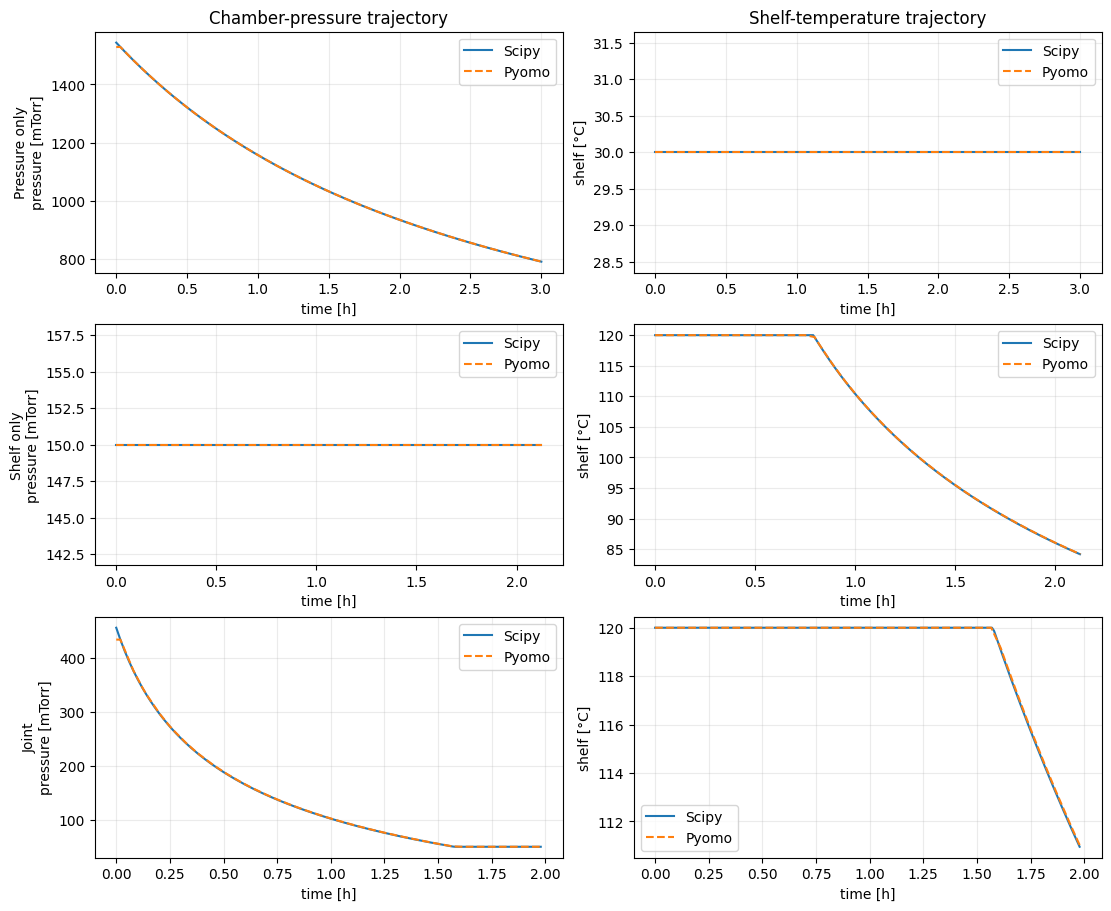

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(11, 9), layout="constrained")
for row, (label, runs) in enumerate(comparisons.items()):
    for backend, style in (("scipy", "-"), ("pyomo", "--")):
        table = runs[backend].trajectory
        axes[row, 0].plot(table[:, 0], table[:, 4], style, label=backend.capitalize())
        axes[row, 1].plot(table[:, 0], table[:, 3], style, label=backend.capitalize())
    axes[row, 0].set(ylabel=f"{label}\npressure [mTorr]")
    axes[row, 1].set(ylabel="shelf [°C]")
    for ax in axes[row]:
        ax.set_xlabel("time [h]")
        ax.grid(alpha=0.25)
        ax.legend()
axes[0, 0].set_title("Chamber-pressure trajectory")
axes[0, 1].set_title("Shelf-temperature trajectory")
plt.show()


## How much does the transcription mesh matter?

Refining the mesh separates two error sources. Backward Euler's gap shrinks as points
are added, which is ordinary first-order discretization error. Collocation's gap does
not move, so it is already mesh-converged.

Mesh-converged is not the same as *correct*, and refining only the Pyomo side cannot
show where the remaining gap comes from. The SciPy reference is itself a discretization
with finite step size, so the second table refines it too. If the reference is the
binding limit, its value should march toward the mesh-stable collocation value as its
step halves — which is what the runs below check.


case              points  Euler [%]  Euler [s]  colloc [%]  colloc [s]
Pressure only         25      0.700      0.050       0.052       0.051
Pressure only         49      0.376      0.068       0.052       0.075
Pressure only         73      0.268      0.091       0.052       0.112
Shelf only            25      0.950      0.050       0.100       0.049
Shelf only            49      0.525      0.079       0.098       0.081
Shelf only            73      0.382      0.221       0.097       0.141
Joint                 25      1.686      0.075       0.185       0.085
Joint                 49      0.940      0.086       0.184       0.093
Joint                 73      0.689      0.119       0.184       0.111


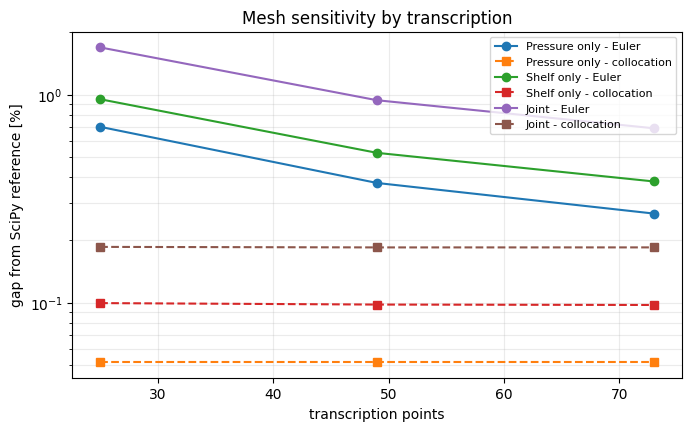

case             SciPy dt=0.02 [h] SciPy dt=0.01 [h]SciPy dt=0.005 [h]   collocation [h]  ref steps at min dt
Pressure only             2.999454          3.001013          3.001792          3.002570                  602
Shelf only                2.120914          2.122961          2.123988          2.125040                  426
Joint                     1.974920          1.978589          1.980416          1.982236                  398

Reference sizes at the headline step: Pressure only 302 steps, Shelf only 214 steps, Joint 199 steps
Each reference refinement moves toward the mesh-stable collocation value, so the residual gap is the reference's remaining discretization error rather than collocation's.


In [5]:
sensitivity_specs = {
    "Pressure only": (pressure_sensitivity, comparisons["Pressure only"]["scipy"]),
    "Shelf only": (shelf_sensitivity, comparisons["Shelf only"]["scipy"]),
    "Joint": (joint_sensitivity, comparisons["Joint"]["scipy"]),
}
budgets = [int(value) for value in sensitivity_point_budgets]

sensitivity = {}
for label, (runner, scipy_run) in sensitivity_specs.items():
    rows = runner(
        a1,
        kc,
        scipy_run.trajectory,
        point_budgets=budgets,
        ncp=ncp,
        final_dried_fraction=final_dried_fraction,
    )
    grid = {}
    for row in rows:
        grid.setdefault(row["point_budget"], {})[row["method"]] = (
            row["objective_gap_percent"],
            row["wall_time_s"],
        )
    sensitivity[label] = grid

# Runtime is shown beside the accuracy it buys, never on its own.
print(
    f"{'case':<16}{'points':>8}{'Euler [%]':>11}{'Euler [s]':>11}"
    f"{'colloc [%]':>12}{'colloc [s]':>12}"
)
for label, grid in sensitivity.items():
    for points in budgets:
        euler_gap, euler_s = grid[points]["finite_difference"]
        colloc_gap, colloc_s = grid[points]["collocation"]
        print(
            f"{label:<16}{points:8d}{euler_gap:11.3f}{euler_s:11.3f}"
            f"{colloc_gap:12.3f}{colloc_s:12.3f}"
        )

# Euler must improve with refinement; collocation should already be at its floor.
for label, grid in sensitivity.items():
    euler = [grid[points]["finite_difference"][0] for points in budgets]
    collocation = [grid[points]["collocation"][0] for points in budgets]
    if len(budgets) > 1:
        assert euler[-1] < euler[0]
        assert abs(collocation[-1] - collocation[0]) < 0.05
        assert abs(collocation[-1]) < abs(euler[-1])

fig, ax = plt.subplots(figsize=(6.8, 4.2), layout="constrained")
for label, grid in sensitivity.items():
    ax.plot(budgets, [grid[p]["finite_difference"][0] for p in budgets], "o-", label=f"{label} - Euler")
    ax.plot(budgets, [grid[p]["collocation"][0] for p in budgets], "s--", label=f"{label} - collocation")
ax.set(xlabel="transcription points", ylabel="gap from SciPy reference [%]",
       title="Mesh sensitivity by transcription")
ax.set_yscale("log")
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=8)
plt.show()

# Refining only the Pyomo mesh cannot attribute the residual gap. Refine the
# reference as well and check that it moves toward the mesh-stable value.
scipy_dts = sorted((float(value) for value in scipy_refinement_dt_values), reverse=True)
reference_refinement = {}
for label, (_, scipy_run) in sensitivity_specs.items():
    runner = {"Pressure only": run_pressure_scipy, "Shelf only": run_shelf_scipy,
              "Joint": run_joint_scipy}[label]
    series = {}
    for dt in scipy_dts:
        run = runner(a1, kc, dt=dt)
        assert run.success
        series[dt] = (run.objective_time_hr, run.n_time_points)
    reference_refinement[label] = series

collocation_time = {
    label: comparisons[label]["pyomo"].objective_time_hr for label in sensitivity_specs
}

header = "".join(f"{f'SciPy dt={dt:g} [h]':>18}" for dt in scipy_dts)
print(f"{'case':<16}{header}{'collocation [h]':>18}{'ref steps at min dt':>21}")
for label, series in reference_refinement.items():
    row = "".join(f"{series[dt][0]:18.6f}" for dt in scipy_dts)
    print(f"{label:<16}{row}{collocation_time[label]:18.6f}{series[scipy_dts[-1]][1]:21d}")

# The reference must approach the mesh-stable collocation value as its step halves.
for label, series in reference_refinement.items():
    times = [series[dt][0] for dt in scipy_dts]
    gaps = [abs(collocation_time[label] - value) for value in times]
    assert times == sorted(times), label
    assert gaps == sorted(gaps, reverse=True), label

reference_points = {
    label: comparisons[label]["scipy"].n_time_points for label in sensitivity_specs
}
print(
    "\nReference sizes at the headline step: "
    + ", ".join(f"{label} {points} steps" for label, points in reference_points.items())
)
print(
    "Each reference refinement moves toward the mesh-stable collocation value, so the "
    "residual gap is the reference's remaining discretization error rather than "
    "collocation's."
)


## Capability comparison

| Capability | SciPy optimizer | Pyomo backend |
| --- | --- | --- |
| Pressure-only, shelf-only, and joint cases | Yes | Yes |
| Primary-drying calculation | Advances one time step at a time | Simultaneous trajectory model |
| Completion-time handling | Integrates until drying is complete | Free final time is a decision variable |
| Control coupling across time | Not available in the legacy optimizers | Initial values and adjacent-node rate limits in the joint DAE model |
| Discretization | User-selected time step | Backward finite difference or Radau collocation |
| Warm start from a legacy trajectory | Not applicable | Available |
| Solver diagnostics | Seven-column trajectory and warnings | Status, termination condition, violations, model size, iterations |
| Shadow prices for active limits | No | Available when the NLP solver exports multipliers |
| Parameter estimation, design-space, sensitivity, robust/scenario, and multi-vial model builders | Separate legacy tools or not available | Available as optional fixed-horizon Pyomo prototypes |
| Installation and API status | Default dependency; stable legacy API | Optional Pyomo/IPOPT stack; experimental API |

The equivalent paper cases should produce the same answer. Pyomo's advantage is the set of formulations that can be added around the same physics, not a different nominal drying time.


## Headline: the fastest implementable cycle

Validation established that both backends agree. This is the result the tutorial is
for, and it is the one only Pyomo.DAE can produce: the sequential optimizer cannot
express constraints that couple successive control decisions.

Four counterfactual solves separate the causes of the penalty rather than assigning
it silently:

1. **Idealized** — no fixed starting controls, no slew limits.
2. **Anchored only** — operational starting controls, but the next node may jump.
3. **Pressure preconditioned** — pressure starts at its floor; shelf start and both rates retained.
4. **Implementable** — both operational starts and both rate limits.

The decomposition is additive but its terms are *signed*, and this case shows why that
matters: preconditioning pressure to its unconstrained optimum is not automatically
faster once rates bind.


In [6]:
analysis = run_implementability_analysis(
    a1,
    kc,
    point_budget=point_budget,
    ncp=ncp,
    final_dried_fraction=final_dried_fraction,
    initial_pressure_torr=initial_pressure_torr,
    initial_shelf_temperature_c=initial_shelf_temperature_c,
    pressure_ramp_rate_torr_hr=pressure_ramp_rate_torr_hr,
    shelf_temperature_ramp_rate_c_hr=shelf_temperature_ramp_rate_c_hr,
)

scenarios = (
    ("idealized, rate-unlimited", analysis.idealized),
    ("anchored starts, jumps unlimited", analysis.anchored_unlimited),
    ("pressure preconditioned to floor", analysis.pressure_preconditioned),
    ("fully implementable", analysis.implementable),
)
baseline = analysis.idealized.objective_time_hr
print(f"{'scenario':<36}{'time [h]':>10}{'vs idealized [h]':>18}{'vs idealized [%]':>18}")
for label, run in scenarios:
    delta = run.objective_time_hr - baseline
    print(f"{label:<36}{run.objective_time_hr:10.4f}{delta:18.4f}{100.0 * delta / baseline:18.2f}")

print(
    f"\nanchor-only {analysis.anchor_only_penalty_hr:+.4f} h | "
    f"rate + interaction {analysis.rate_and_interaction_penalty_hr:+.4f} h | "
    f"pressure-start {analysis.pressure_start_penalty_hr:+.4f} h"
)

# Fixed starts alone cost essentially nothing; the penalty is the rate limits.
assert abs(analysis.anchor_only_penalty_hr) < 1.0e-3
assert analysis.total_penalty_hr > 0.0
assert abs(
    analysis.total_penalty_hr
    - (analysis.anchor_only_penalty_hr + analysis.rate_and_interaction_penalty_hr)
) < 1.0e-9
print(
    "Fixed starting controls alone cost nothing measurable; the entire penalty comes "
    "from the rate limits and their interaction with those starts."
)


scenario                              time [h]  vs idealized [h]  vs idealized [%]
idealized, rate-unlimited               1.9822            0.0000              0.00
anchored starts, jumps unlimited        1.9822           -0.0000             -0.00
pressure preconditioned to floor        3.0212            1.0390             52.41
fully implementable                     2.8284            0.8462             42.69

anchor-only -0.0000 h | rate + interaction +0.8462 h | pressure-start -0.1928 h
Fixed starting controls alone cost nothing measurable; the entire penalty comes from the rate limits and their interaction with those starts.


## Would faster actuators buy useful cycle time?

The penalty above is quoted at one pair of slew rates. Sweeping the shelf rate across
the range real equipment spans turns the shadow-price question into a capital one: how
much cycle time does a faster controller actually return?


  shelf rate [degC/hr]   degC/min   time [h]  penalty [%]
                    15       0.25     3.1961        61.23
                    30       0.50     2.8284        42.69
                    60       1.00     2.5319        27.73


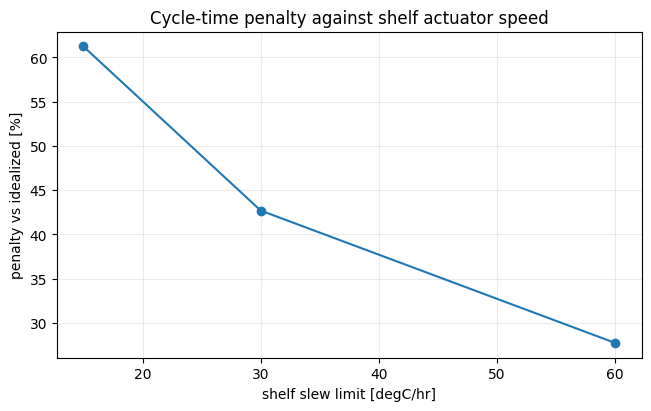

In [7]:
sweep_rows = run_slew_rate_sweep(
    a1,
    kc,
    idealized_time_hr=analysis.idealized.objective_time_hr,
    point_budget=point_budget,
    ncp=ncp,
    final_dried_fraction=final_dried_fraction,
    initial_pressure_torr=initial_pressure_torr,
    initial_shelf_temperature_c=initial_shelf_temperature_c,
    pressure_ramp_rates_torr_hr=[pressure_ramp_rate_torr_hr],
    shelf_temperature_ramp_rates_c_hr=shelf_sweep_rates_c_hr,
)
sweep_rows.sort(key=lambda row: row["shelf_temperature_ramp_rate_c_hr"])

print(f"{'shelf rate [degC/hr]':>22}{'degC/min':>11}{'time [h]':>11}{'penalty [%]':>13}")
for row in sweep_rows:
    rate = row["shelf_temperature_ramp_rate_c_hr"]
    print(
        f"{rate:22.0f}{rate / 60.0:11.2f}{row['objective_time_hr']:11.4f}"
        f"{row['penalty_percent']:13.2f}"
    )

# A faster shelf can never lengthen the cycle.
penalties = [row["penalty_percent"] for row in sweep_rows]
assert penalties == sorted(penalties, reverse=True)

fig, ax = plt.subplots(figsize=(6.4, 4.0), layout="constrained")
ax.plot([row["shelf_temperature_ramp_rate_c_hr"] for row in sweep_rows], penalties, "o-")
ax.set(xlabel="shelf slew limit [degC/hr]", ylabel="penalty vs idealized [%]",
       title="Cycle-time penalty against shelf actuator speed")
ax.grid(alpha=0.25)
plt.show()


## Do the exported controls actually respect the limits?

The headline cycle is only credible if its trajectory honors the slew limits it
was solved under. This section verifies the exported controls of that same solve
against both bounds and plots them beside the idealized policy.


In [8]:
# Verify the cycle the headline reports, rather than solving it again.
idealized = analysis.idealized
rate_limited = analysis.implementable
assert rate_limited.success

table = rate_limited.trajectory
time_steps = np.diff(table[:, 0])  # [h]
pressure_rates = np.abs(np.diff(table[:, 4]) / 1000.0) / time_steps  # [Torr/h]
shelf_rates = np.abs(np.diff(table[:, 3])) / time_steps  # [°C/h]
assert np.max(pressure_rates) <= pressure_ramp_rate_torr_hr + 1.0e-4
assert np.max(shelf_rates) <= shelf_temperature_ramp_rate_c_hr + 1.0e-4

penalty_hr = rate_limited.objective_time_hr - idealized.objective_time_hr
print(f"Idealized Pyomo joint case: {idealized.objective_time_hr:.3f} h")
print(f"Rate-limited Pyomo case:     {rate_limited.objective_time_hr:.3f} h")
print(f"Added drying time:           {penalty_hr:.3f} h")


Idealized Pyomo joint case: 1.982 h
Rate-limited Pyomo case:     2.828 h
Added drying time:           0.846 h


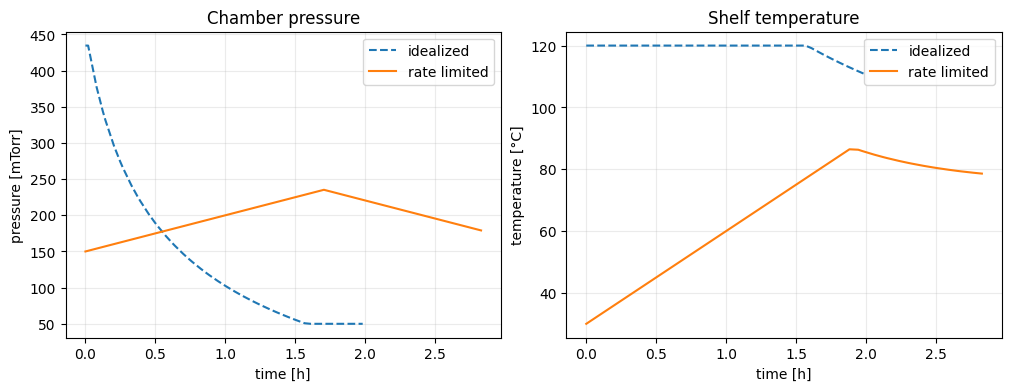


limit                                  shadow price        units
product_temperature_limit                  -0.12354         h/°C
equipment_capability                   -1.78511e-09     h/(kg/h)
chamber_pressure_lower_bound                0.13023       h/Torr
chamber_pressure_upper_bound           -1.70889e-09       h/Torr
shelf_temperature_lower_bound           2.98856e-12         h/°C
shelf_temperature_upper_bound           -0.00215607         h/°C


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), layout="constrained")
for label, run, style in (
    ("idealized", idealized, "--"),
    ("rate limited", rate_limited, "-"),
):
    table = run.trajectory
    axes[0].plot(table[:, 0], table[:, 4], style, label=label)
    axes[1].plot(table[:, 0], table[:, 3], style, label=label)
axes[0].set(title="Chamber pressure", xlabel="time [h]", ylabel="pressure [mTorr]")
axes[1].set(title="Shelf temperature", xlabel="time [h]", ylabel="temperature [°C]")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

shadow_units = {
    "product_temperature_limit": "h/°C",
    "equipment_capability": "h/(kg/h)",
    "chamber_pressure_lower_bound": "h/Torr",
    "chamber_pressure_upper_bound": "h/Torr",
    "shelf_temperature_lower_bound": "h/°C",
    "shelf_temperature_upper_bound": "h/°C",
}
print(f"\n{'limit':<36} {'shadow price':>14} {'units':>12}")
for name, value in idealized.shadow_prices.items():
    if name in shadow_units:
        print(f"{name:<36} {value:14.6g} {shadow_units[name]:>12}")


## Pyomo-only extension: what is each constraint worth?

The solve already carries the answer to a question the sequential optimizer cannot
express. Because the objective *is* the final drying time, each constraint multiplier
is a derivative of drying time with respect to a limit — hours per unit of relaxation.

Raw prices cannot be ranked against each other, because their units differ: h/Torr and
h/degC are not comparable increments. Each lever is therefore priced over a stated,
plausible improvement, which puts every row in hours. A price near zero means the limit
is inactive at the optimum, so buying more of it returns nothing. Prices are local
sensitivities around one active set, so the best lever is re-solved to confirm it.


In [10]:
# Price each lever over a stated realistic improvement so the rows are comparable.
improvements = {
    "product_temperature_limit": (+1.0, "degC more product headroom"),
    "chamber_pressure_lower_bound": (-0.01, "Torr lower pressure floor"),
    "shelf_temperature_upper_bound": (+5.0, "degC higher shelf ceiling"),
    "equipment_capability": (+0.1, "kg/h more condenser capacity"),
}

rows = []
for name, (step, description) in improvements.items():
    price = idealized.shadow_prices.get(name, 0.0)
    rows.append((name, price, step, description, price * step))
rows.sort(key=lambda row: row[4])

print(f"{'lever':<32}{'price':>12}{'units':>12}{'hours':>10}   improvement")
for name, price, step, description, hours in rows:
    print(
        f"{name:<32}{price:12.4f}{shadow_units[name]:>12}{hours:10.4f}   "
        f"{step:+g} {description}"
    )

best_name, best_price, best_step, best_description, best_hours = rows[0]
print(f"\nBest lever over these increments: {best_name} ({best_hours:+.4f} h)")

# Confirm the winning price against an independent re-solve.
joint_case = joint_inputs(a1, kc)
relaxed_product = dict(joint_case["product"])
relaxed_product["T_pr_crit"] = relaxed_product["T_pr_crit"] + 1.0
relaxed = solve_dae_joint_optimization(
    joint_case["vial"],
    relaxed_product,
    joint_case["ht"],
    joint_case["pchamber"],
    joint_case["tshelf"],
    eq_cap=joint_case["eq_cap"],
    nvial=joint_case["nvial"],
    nfe=collocation_nfe,
    discretization="collocation",
    ncp=ncp,
    final_dried_fraction=final_dried_fraction,
)
assert relaxed.success
assert best_name == "product_temperature_limit", best_name

predicted_hr = idealized.shadow_prices["product_temperature_limit"] * 1.0
observed_hr = relaxed.objective_time_hr - idealized.objective_time_hr
assert abs(predicted_hr - observed_hr) <= 0.25 * abs(observed_hr)

print(
    f"1 degC more headroom: predicted {predicted_hr:+.4f} h, "
    f"re-solved {observed_hr:+.4f} h "
    f"({100.0 * abs(predicted_hr - observed_hr) / abs(observed_hr):.1f}% apart)"
)
print(
    "Product-temperature headroom is worth roughly two orders of magnitude more than "
    "a comparable vacuum improvement here, and condenser capacity is worth nothing "
    "because it is not binding. The sequential SciPy optimizer reports the optimal "
    "cycle but no equivalent of these prices."
)


lever                                  price       units     hours   improvement
product_temperature_limit            -0.1235        h/°C   -0.1235   +1 degC more product headroom
shelf_temperature_upper_bound        -0.0022        h/°C   -0.0108   +5 degC higher shelf ceiling
chamber_pressure_lower_bound          0.1302      h/Torr   -0.0013   -0.01 Torr lower pressure floor
equipment_capability                 -0.0000    h/(kg/h)   -0.0000   +0.1 kg/h more condenser capacity

Best lever over these increments: product_temperature_limit (-0.1235 h)


1 degC more headroom: predicted -0.1235 h, re-solved -0.1169 h (5.7% apart)
Product-temperature headroom is worth roughly two orders of magnitude more than a comparable vacuum improvement here, and condenser capacity is worth nothing because it is not binding. The sequential SciPy optimizer reports the optimal cycle but no equivalent of these prices.


## Scope

This notebook uses the paper's mannitol example because all three optimizer modes are defined for the same physical case. The current results are close to the published times; small differences reflect current solver tolerances, exact terminal drying, and discretization.

The rate-limited model still uses quasi-steady product physics. It constrains the control sequence but does not model shelf, vial, or product thermal capacitance. A useful next backend step would be to combine the free-final-time DAE formulation with the existing robust/scenario and parameter-estimation prototypes, then add equipment thermal dynamics before treating rate-limited trajectories as controller-ready cycles.
